# Raw-feature Bayesian Network with Hill Climb Structure Learning

This notebook is based on the original Bayesian Network workflow, but intentionally removes the manual cleaning, diagnosis mappings, recoding, imputation, and feature engineering steps.

The only transformations kept are the minimum required to train a discrete Bayesian Network in `pgmpy`:

- preserve raw dataset columns as features
- split train/validation/test before learning preprocessing parameters
- convert missing values to an explicit `Missing` state
- cap very rare categories to keep conditional probability tables tractable
- discretize numeric columns into quantile bins learned from the training split

The workflow uses hill-climb structure learning to discover relations between raw features, trains Bayesian Networks, selects the best configuration on validation data, and reports final predictive metrics on a held-out test set.

## Setup

Run this notebook in Colab from top to bottom. The code is written to avoid data leakage: feature ranking, category caps, and numeric bins are learned from training data only.

In [24]:
!pip -q install "pgmpy>=0.1.26" "scikit-learn>=1.4" "networkx>=3.0" "joblib>=1.3" "gdown>=5.0"

In [25]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, label_binarize
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import normalized_mutual_info_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

RANDOM_STATE = 42
TARGET = "readmitted"
ID_COLUMNS = ["encounter_id", "patient_nbr"]

## Load Raw Data

This uses the same dataset link as the original notebook. No cleaning or manual mappings are applied after loading.

In [26]:
import gdown

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "diabetic_data.csv"
DRIVE_URL = "https://drive.google.com/file/d/1qtACu4wjaIRsYp9bfYZs7uMvVkdyiqEw/view?usp=sharing"

if not DATA_PATH.exists():
    gdown.download(DRIVE_URL, str(DATA_PATH), quiet=False, fuzzy=True)
else:
    print(f"Using cached file: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())
display(df_raw[TARGET].value_counts(normalize=True).rename("class_rate"))

Using cached file: /content/data/diabetic_data.csv
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,class_rate
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


## Train / Validation / Test Split

The validation split is used to choose the feature count and hill-climb configuration. The final test split is touched only once at the end.

In [27]:
feature_candidates = [
    col for col in df_raw.columns
    if col not in ID_COLUMNS + [TARGET]
]

# Remove constants using training data only after the split below.
trainval_raw, test_raw = train_test_split(
    df_raw,
    test_size=0.20,
    stratify=df_raw[TARGET],
    random_state=RANDOM_STATE,
)

train_raw, val_raw = train_test_split(
    trainval_raw,
    test_size=0.20,
    stratify=trainval_raw[TARGET],
    random_state=RANDOM_STATE,
)

constant_features = [
    col for col in feature_candidates
    if train_raw[col].nunique(dropna=False) <= 1
]
feature_candidates = [col for col in feature_candidates if col not in constant_features]

print(f"Train rows:      {len(train_raw):,}")
print(f"Validation rows: {len(val_raw):,}")
print(f"Test rows:       {len(test_raw):,}")
print(f"Raw candidate features: {len(feature_candidates)}")
if constant_features:
    print("Dropped constant features:", constant_features)

Train rows:      65,129
Validation rows: 16,283
Test rows:       20,354
Raw candidate features: 42
Dropped constant features: ['acetohexamide', 'troglitazone', 'examide', 'citoglipton', 'metformin-pioglitazone']


## Feature Ranking From Raw Columns

The Bayesian Network search gets slow and unstable when every raw field is included. We rank raw columns by mutual information with `readmitted`, then use a redundancy filter so the selected features are informative without being near-duplicates.

This is not manual mapping: categorical values are ordinal-encoded only so `mutual_info_classif` can score them.

,feature,mutual_information,n_unique_train,dtype
0,number_inpatient,0.032483,19,int64
1,diag_1,0.028526,684,object
2,diag_3,0.024031,733,object
3,diag_2,0.024012,680,object
4,discharge_disposition_id,0.020481,25,int64
5,number_outpatient,0.010265,36,int64
6,admission_source_id,0.008485,16,int64
7,number_diagnoses,0.008333,16,int64
8,number_emergency,0.007846,26,int64
9,medical_specialty,0.007329,69,object


Selected diverse raw feature pool (30 features):
['number_inpatient', 'diag_1', 'diag_3', 'diag_2', 'discharge_disposition_id', 'number_outpatient', 'admission_source_id', 'number_diagnoses', 'number_emergency', 'medical_specialty', 'time_in_hospital', 'num_medications', 'insulin', 'payer_code', 'admission_type_id', 'diabetesMed', 'age', 'race', 'weight', 'change', 'num_lab_procedures', 'metformin', 'A1Cresult', 'glipizide', 'gender', 'rosiglitazone', 'max_glu_serum', 'repaglinide', 'acarbose', 'pioglitazone']


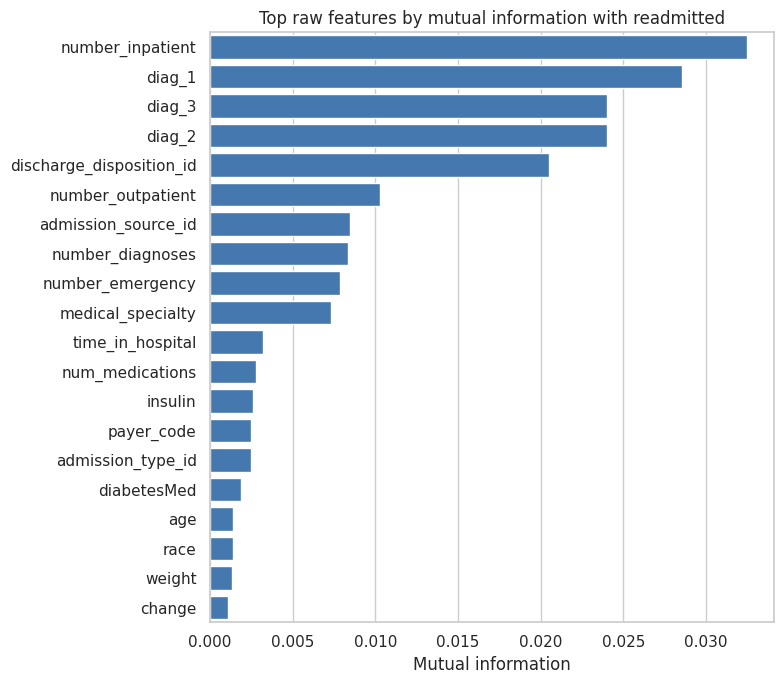

In [28]:
def _as_mi_matrix(train_df, columns):
    """Build a mixed numeric/categorical matrix for mutual information scoring."""
    parts = []
    discrete_mask = []

    for col in columns:
        series = train_df[col]
        if pd.api.types.is_numeric_dtype(series):
            numeric = pd.to_numeric(series, errors="coerce")
            fill_value = numeric.median()
            if pd.isna(fill_value):
                fill_value = 0
            parts.append(numeric.fillna(fill_value).to_frame(col))
            discrete_mask.append(False)
        else:
            values = series.astype("object").where(series.notna(), "Missing").astype(str).to_frame(col)
            enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
            encoded = pd.DataFrame(enc.fit_transform(values), columns=[col], index=train_df.index)
            parts.append(encoded)
            discrete_mask.append(True)

    return pd.concat(parts, axis=1), np.array(discrete_mask, dtype=bool)


def rank_raw_features(train_df, columns, target=TARGET, random_state=RANDOM_STATE):
    X_mi, discrete_mask = _as_mi_matrix(train_df, columns)
    y = train_df[target].astype(str)
    mi = mutual_info_classif(
        X_mi,
        y,
        discrete_features=discrete_mask,
        random_state=random_state,
    )
    out = pd.DataFrame({"feature": columns, "mutual_information": mi})
    out["n_unique_train"] = [train_df[col].nunique(dropna=False) for col in columns]
    out["dtype"] = [str(train_df[col].dtype) for col in columns]
    return out.sort_values("mutual_information", ascending=False).reset_index(drop=True)


def select_diverse_features(train_df, ranked_features, max_features=30, redundancy_threshold=0.90):
    """Greedy mRMR-style filter using normalized MI between raw string columns."""
    selected = []
    encoded_cache = {}

    def encoded(col):
        if col not in encoded_cache:
            values = train_df[col].astype("object").where(train_df[col].notna(), "Missing").astype(str)
            encoded_cache[col] = pd.factorize(values, sort=True)[0]
        return encoded_cache[col]

    for feature in ranked_features:
        if len(selected) >= max_features:
            break
        redundant = False
        for chosen in selected:
            redundancy = normalized_mutual_info_score(encoded(feature), encoded(chosen))
            if redundancy >= redundancy_threshold:
                redundant = True
                break
        if not redundant:
            selected.append(feature)
    return selected


mi_scores = rank_raw_features(train_raw, feature_candidates)
display(mi_scores.head(25))

MAX_RANKED_FEATURES = 30
ranked_feature_pool = select_diverse_features(
    train_raw,
    mi_scores["feature"].tolist(),
    max_features=MAX_RANKED_FEATURES,
    redundancy_threshold=0.90,
)

print(f"Selected diverse raw feature pool ({len(ranked_feature_pool)} features):")
print(ranked_feature_pool)

plt.figure(figsize=(8, 7))
sns.barplot(
    data=mi_scores.head(20),
    y="feature",
    x="mutual_information",
    color="#3478bf",
)
plt.title("Top raw features by mutual information with readmitted")
plt.xlabel("Mutual information")
plt.ylabel("")
plt.tight_layout()

## Minimal Raw-to-Discrete Preparation

`pgmpy` Bayesian Networks are discrete here, so every selected raw feature must become a finite set of states. This class does that without diagnosis mappings or manual clinical recoding.

Important details:

- `fit` learns numeric bin edges and top categories from the training split only.
- Unknown validation/test categories become `Other`.
- Raw `?` values are preserved as literal categories; true pandas missing values become `Missing`.

In [29]:
class RawDiscretePreprocessor:
    def __init__(self, features, target=TARGET, numeric_bins=4, max_categories=12):
        self.features = list(features)
        self.target = target
        self.numeric_bins = numeric_bins
        self.max_categories = max_categories
        self.numeric_bin_edges_ = {}
        self.numeric_labels_ = {}
        self.category_levels_ = {}
        self.numeric_as_category_ = set()

    def fit(self, df):
        for col in self.features:
            series = df[col]
            if pd.api.types.is_numeric_dtype(series) and series.nunique(dropna=True) > self.numeric_bins:
                values = pd.to_numeric(series, errors="coerce").dropna()
                if values.nunique() > 1:
                    _, edges = pd.qcut(
                        values,
                        q=min(self.numeric_bins, values.nunique()),
                        retbins=True,
                        duplicates="drop",
                    )
                    edges = np.unique(edges)
                    if len(edges) > 2:
                        edges[0] = -np.inf
                        edges[-1] = np.inf
                        self.numeric_bin_edges_[col] = edges
                        self.numeric_labels_[col] = [f"Bin_{i}" for i in range(1, len(edges))]
                        continue
            self.numeric_as_category_.add(col)
            self.category_levels_[col] = self._top_categories(series)
        return self

    def _top_categories(self, series):
        values = series.astype("object").where(series.notna(), "Missing").astype(str)
        top_n = max(self.max_categories - 2, 1)  # leave room for Other/Missing
        return values.value_counts().head(top_n).index.tolist()

    def _transform_feature(self, df, col):
        series = df[col]
        if col in self.numeric_bin_edges_:
            values = pd.to_numeric(series, errors="coerce")
            out = pd.cut(
                values,
                bins=self.numeric_bin_edges_[col],
                labels=self.numeric_labels_[col],
                include_lowest=True,
            ).astype("object")
            return out.where(out.notna(), "Missing").astype(str)

        values = series.astype("object").where(series.notna(), "Missing").astype(str)
        known = set(self.category_levels_[col]) | {"Missing", "Other"}
        return values.where(values.isin(known), "Other").astype(str)

    def transform(self, df):
        out = pd.DataFrame(index=df.index)
        for col in self.features:
            out[col] = self._transform_feature(df, col)
        out[self.target] = df[self.target].astype("object").where(df[self.target].notna(), "Missing").astype(str)
        return out.reset_index(drop=True)

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def stratified_sample(df, n_samples, target=TARGET, random_state=RANDOM_STATE):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)
    sample, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df[target],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)

## Hill-Climb Bayesian Network Helpers

These helpers keep the notebook compatible with common `pgmpy` versions. Hill climb learns the graph structure; Bayesian parameter estimation with a BDeu prior smooths conditional probability tables so rare states are less brittle.

In [30]:
def get_bn_class():
    try:
        from pgmpy.models import DiscreteBayesianNetwork
        return DiscreteBayesianNetwork
    except ImportError:
        from pgmpy.models import BayesianNetwork
        return BayesianNetwork


def make_structure_score(data, score_name):
    score_name = score_name.lower()
    if score_name == "bic":
        try:
            from pgmpy.estimators import BicScore
            return BicScore(data)
        except ImportError:
            from pgmpy.estimators import BIC
            return BIC(data)
    if score_name == "k2":
        try:
            from pgmpy.estimators import K2Score
            return K2Score(data)
        except ImportError:
            from pgmpy.estimators import K2
            return K2(data)
    if score_name == "bdeu":
        try:
            from pgmpy.estimators import BDeuScore
            return BDeuScore(data, equivalent_sample_size=10)
        except ImportError:
            from pgmpy.estimators import BDeu
            return BDeu(data, equivalent_sample_size=10)
    raise ValueError(f"Unknown score_name: {score_name}")


def learn_structure_hill_climb(structure_df, score_name="bic", max_indegree=3, tabu_length=100):
    structure_df = structure_df.astype(str)
    score_name = score_name.lower()

    # pgmpy >= 1.0 introduced a causal_discovery hill-climb API.
    # It currently maps most directly to discrete BIC scoring.
    if score_name == "bic":
        try:
            from pgmpy.causal_discovery import HillClimbSearch as CausalHillClimbSearch
            hc = CausalHillClimbSearch(
                scoring_method="bic-d",
                return_type="dag",
                max_indegree=max_indegree,
                show_progress=False,
            )
            hc.fit(structure_df)
            graph = getattr(hc, "causal_graph_", None)
            if graph is not None:
                return list(graph.edges())
        except Exception:
            pass

    from pgmpy.estimators import HillClimbSearch

    hc = HillClimbSearch(structure_df)
    score = make_structure_score(structure_df, score_name)
    dag = hc.estimate(
        scoring_method=score,
        max_indegree=max_indegree,
        tabu_length=tabu_length,
        show_progress=False,
    )
    return list(dag.edges())


def fit_bn_model(train_df, edges, equivalent_sample_size=10):
    from pgmpy.estimators import BayesianEstimator

    train_df = train_df.astype(str)
    BNClass = get_bn_class()
    model = BNClass()
    model.add_nodes_from(train_df.columns)
    model.add_edges_from(edges)

    # Colab/pgmpy versions differ in what model.fit forwards to BayesianEstimator.
    # Build and attach CPDs directly so BDeu smoothing works across versions.
    estimator = BayesianEstimator(model, train_df)
    cpds = estimator.get_parameters(
        prior_type="BDeu",
        equivalent_sample_size=equivalent_sample_size,
    )
    model.add_cpds(*cpds)
    model.check_model()
    return model


def train_bn_pipeline(
    raw_train_df,
    features,
    score_name="bic",
    max_indegree=3,
    max_categories=12,
    numeric_bins=4,
    structure_sample_size=15_000,
    equivalent_sample_size=10,
):
    preprocessor = RawDiscretePreprocessor(
        features,
        numeric_bins=numeric_bins,
        max_categories=max_categories,
    )
    train_bn_df = preprocessor.fit_transform(raw_train_df)
    structure_df = stratified_sample(train_bn_df, structure_sample_size)
    edges = learn_structure_hill_climb(
        structure_df,
        score_name=score_name,
        max_indegree=max_indegree,
    )
    model = fit_bn_model(
        train_bn_df,
        edges,
        equivalent_sample_size=equivalent_sample_size,
    )
    return model, preprocessor, train_bn_df, edges


def plot_bn_structure(model, title="Learned Bayesian Network"):
    graph = nx.DiGraph()
    graph.add_nodes_from(model.nodes())
    graph.add_edges_from(model.edges())

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE, k=0.9)
    colors = ["#e15759" if node == TARGET else "#4e79a7" for node in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=1600, alpha=0.95)
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.4)
    nx.draw_networkx_labels(graph, pos, font_size=9, font_color="white")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

In [31]:
def predict_bn_probabilities(model, bn_df, target=TARGET, batch_size=1_000):
    labels = list(model.get_cpds(target).state_names[target])
    feature_cols = [col for col in bn_df.columns if col != target]
    frames = []

    for start in range(0, len(bn_df), batch_size):
        batch = bn_df.iloc[start:start + batch_size]
        pred = model.predict_probability(batch[feature_cols])

        if target in pred.columns:
            arr = np.vstack(pred[target].to_numpy())
            frame = pd.DataFrame(arr, columns=labels, index=batch.index)
        else:
            expected = [f"{target}_{label}" for label in labels]
            frame = pred.reindex(columns=expected, fill_value=0.0).copy()
            frame.columns = labels
        frames.append(frame.astype(float))

    prob_df = pd.concat(frames).sort_index()
    row_sums = prob_df.sum(axis=1).replace(0, np.nan)
    prob_df = prob_df.div(row_sums, axis=0).fillna(1 / len(labels))
    return prob_df[labels]


def evaluate_bn_model(model, preprocessor, raw_eval_df, target=TARGET, name="model"):
    eval_bn_df = preprocessor.transform(raw_eval_df)
    y_true = eval_bn_df[target].astype(str).to_numpy()
    prob_df = predict_bn_probabilities(model, eval_bn_df, target=target)
    labels = prob_df.columns.tolist()
    y_pred = prob_df.idxmax(axis=1).to_numpy()

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, prob_df.to_numpy(), labels=labels),
        "brier_multiclass": np.mean(
            np.sum((pd.get_dummies(pd.Categorical(y_true, categories=labels)).to_numpy() - prob_df.to_numpy()) ** 2, axis=1)
        ),
        "n_edges": len(model.edges()),
        "max_parents": max((len(list(model.predecessors(node))) for node in model.nodes()), default=0),
    }

    try:
        y_binary = label_binarize(y_true, classes=labels)
        metrics["roc_auc_ovr_macro"] = roc_auc_score(y_binary, prob_df.to_numpy(), average="macro", multi_class="ovr")
        metrics["pr_auc_macro"] = average_precision_score(y_binary, prob_df.to_numpy(), average="macro")
    except ValueError:
        metrics["roc_auc_ovr_macro"] = np.nan
        metrics["pr_auc_macro"] = np.nan

    return metrics, y_true, y_pred, prob_df


def evaluate_majority_baseline(train_df, eval_df, target=TARGET):
    clf = DummyClassifier(strategy="most_frequent")
    clf.fit(np.zeros((len(train_df), 1)), train_df[target].astype(str))
    y_true = eval_df[target].astype(str).to_numpy()
    y_pred = clf.predict(np.zeros((len(eval_df), 1)))
    return {
        "model": "majority_baseline",
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": np.nan,
        "brier_multiclass": np.nan,
        "roc_auc_ovr_macro": np.nan,
        "pr_auc_macro": np.nan,
        "n_edges": 0,
        "max_parents": 0,
    }


def show_classification_outputs(y_true, y_pred, labels, title="Confusion matrix"):
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

## Model Selection

This grid searches feature count, hill-climb score, maximum parents per node, category cap, and numeric bin count. Increase the grid if you have more Colab runtime; decrease `STRUCTURE_SAMPLE_SIZE` if hill climb is too slow.

Primary selection metric is validation `macro_f1`, because the readmission classes are imbalanced. `log_loss` is used as a tie-breaker because it rewards calibrated probabilities.

In [32]:
# Default grid: 24 candidate BNs. Expand these lists if you have more Colab runtime.
FEATURE_COUNTS = [8, 12, 16]
SCORE_NAMES = ["bic", "k2"]
MAX_INDEGREES = [2, 3]
MAX_CATEGORY_OPTIONS = [8, 12]
NUMERIC_BIN_OPTIONS = [4]
STRUCTURE_SAMPLE_SIZE = 15_000
EQUIVALENT_SAMPLE_SIZE = 10

selection_rows = []
trained_candidates = {}

for n_features in FEATURE_COUNTS:
    features = ranked_feature_pool[:n_features]
    if len(features) < n_features:
        continue

    for score_name in SCORE_NAMES:
        for max_indegree in MAX_INDEGREES:
            for max_categories in MAX_CATEGORY_OPTIONS:
                for numeric_bins in NUMERIC_BIN_OPTIONS:
                    run_name = (
                        f"top{n_features}_{score_name}_parents{max_indegree}"
                        f"_cat{max_categories}_bins{numeric_bins}"
                    )
                    print(f"\nTraining {run_name}")
                    try:
                        model, preprocessor, train_bn_df, edges = train_bn_pipeline(
                            train_raw,
                            features=features,
                            score_name=score_name,
                            max_indegree=max_indegree,
                            max_categories=max_categories,
                            numeric_bins=numeric_bins,
                            structure_sample_size=STRUCTURE_SAMPLE_SIZE,
                            equivalent_sample_size=EQUIVALENT_SAMPLE_SIZE,
                        )
                        metrics, _, _, _ = evaluate_bn_model(model, preprocessor, val_raw, name=run_name)
                        metrics.update({
                            "n_features": n_features,
                            "score_name": score_name,
                            "max_indegree": max_indegree,
                            "max_categories": max_categories,
                            "numeric_bins": numeric_bins,
                            "features": ", ".join(features),
                        })
                        selection_rows.append(metrics)
                        trained_candidates[run_name] = (model, preprocessor, features)
                        print(
                            f"macro_f1={metrics['macro_f1']:.4f} | "
                            f"balanced_acc={metrics['balanced_accuracy']:.4f} | "
                            f"log_loss={metrics['log_loss']:.4f} | "
                            f"edges={metrics['n_edges']}"
                        )
                    except Exception as exc:
                        print(f"Skipped {run_name}: {type(exc).__name__}: {exc}")

baseline_metrics = evaluate_majority_baseline(train_raw, val_raw)
selection_rows.append(baseline_metrics)

selection_results = pd.DataFrame(selection_rows)
metric_cols = [
    "model", "n_features", "score_name", "max_indegree", "max_categories", "numeric_bins",
    "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "log_loss",
    "roc_auc_ovr_macro", "pr_auc_macro", "brier_multiclass", "n_edges", "max_parents",
]
display(selection_results.reindex(columns=metric_cols).sort_values(
    ["macro_f1", "balanced_accuracy", "log_loss"],
    ascending=[False, False, True],
).head(15))


Training top8_bic_parents2_cat8_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=9

Training top8_bic_parents2_cat12_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=9

Training top8_bic_parents3_cat8_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=9

Training top8_bic_parents3_cat12_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=9

Training top8_k2_parents2_cat8_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=13

Training top8_k2_parents2_cat12_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=13

Training top8_k2_parents3_cat8_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9195 | edges=14

Training top8_k2_parents3_cat12_bins4
macro_f1=0.3401 | balanced_acc=0.3769 | log_loss=0.9173 | edges=17

Training top12_bic_parents2_cat8_bins4
macro_f1=0.3302 | balanced_acc=0.3728 | log_loss=0.9210 | edges=15

Training top12_bic_parents2_cat12_bins4
macro_f1

,model,n_features,score_name,max_indegree,max_categories,numeric_bins,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,roc_auc_ovr_macro,pr_auc_macro,brier_multiclass,n_edges,max_parents
14,top12_k2_parents3_cat8_bins4,12.0,k2,3.0,8.0,4.0,0.569428,0.383250,0.350563,0.500472,0.916021,0.600300,0.396511,0.553810,27,3
22,top16_k2_parents3_cat8_bins4,16.0,k2,3.0,8.0,4.0,0.569428,0.383250,0.350563,0.500472,0.916021,0.600300,0.396511,0.553810,34,3
15,top12_k2_parents3_cat12_bins4,12.0,k2,3.0,12.0,4.0,0.566787,0.378833,0.343638,0.492634,0.920085,0.586358,0.385934,0.555679,27,3
23,top16_k2_parents3_cat12_bins4,16.0,k2,3.0,12.0,4.0,0.566787,0.378833,0.343638,0.492634,0.920085,0.586358,0.385934,0.555679,38,3
7,top8_k2_parents3_cat12_bins4,8.0,k2,3.0,12.0,4.0,0.565805,0.376902,0.340086,0.489491,0.917313,0.601721,0.397918,0.554147,17,3
13,top12_k2_parents2_cat12_bins4,12.0,k2,2.0,12.0,4.0,0.568507,0.377681,0.339220,0.490256,0.919921,0.575138,0.375779,0.557084,20,2
21,top16_k2_parents2_cat12_bins4,16.0,k2,2.0,12.0,4.0,0.568507,0.377681,0.339220,0.490256,0.919921,0.575138,0.375779,0.557084,29,2
12,top12_k2_parents2_cat8_bins4,12.0,k2,2.0,8.0,4.0,0.568691,0.377732,0.339124,0.490428,0.919851,0.575311,0.375781,0.557001,22,2
20,top16_k2_parents2_cat8_bins4,16.0,k2,2.0,8.0,4.0,0.568691,0.377732,0.339124,0.490428,0.919851,0.575311,0.375781,0.557001,26,2
0,top8_bic_parents2_cat8_bins4,8.0,bic,2.0,8.0,4.0,0.565805,0.372809,0.330206,0.481050,0.919508,0.593387,0.386963,0.556652,9,2


## Final Model and Held-Out Test Metrics

After choosing the best validation configuration, retrain it on `train + validation`, then evaluate once on `test`. This gives a cleaner estimate than selecting and reporting on the same split.

Best validation configuration:


,value
model,top12_k2_parents3_cat8_bins4
accuracy,0.569428
balanced_accuracy,0.38325
macro_f1,0.350563
weighted_f1,0.500472
macro_precision,0.486228
macro_recall,0.38325
log_loss,0.916021
brier_multiclass,0.55381
n_edges,27


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,log_loss,roc_auc_ovr_macro,pr_auc_macro,brier_multiclass,n_edges,max_parents
0,majority_baseline,0.539108,0.333333,0.233515,0.37767,0.179703,0.333333,NaN,NaN,NaN,NaN,0,0
1,final_bn,0.567603,0.383453,0.352332,0.50127,0.476017,0.383453,0.916394,0.603699,0.3974,0.554183,27,3


              precision    recall  f1-score   support

         <30       0.36      0.00      0.01      2272
         >30       0.48      0.27      0.34      7109
          NO       0.59      0.88      0.71     10973

    accuracy                           0.57     20354
   macro avg       0.48      0.38      0.35     20354
weighted avg       0.53      0.57      0.50     20354



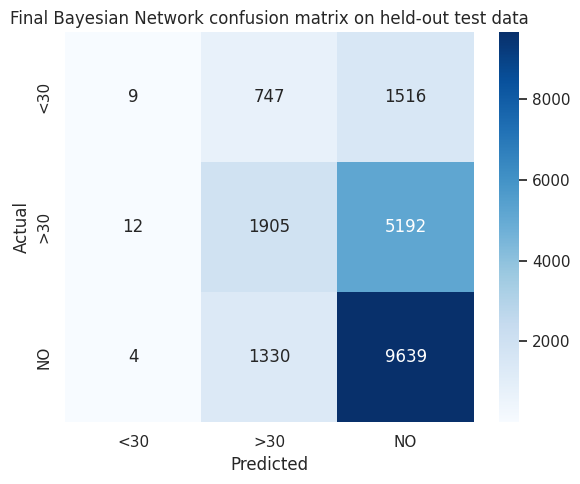

In [33]:
candidate_results = selection_results[selection_results["model"] != "majority_baseline"].copy()
if candidate_results.empty:
    raise RuntimeError("No Bayesian Network candidates trained successfully. Reduce the grid or inspect errors above.")

best_row = candidate_results.sort_values(
    ["macro_f1", "balanced_accuracy", "log_loss"],
    ascending=[False, False, True],
).iloc[0]

best_features = best_row["features"].split(", ")
print("Best validation configuration:")
display(best_row.to_frame("value"))

final_model, final_preprocessor, final_train_bn_df, final_edges = train_bn_pipeline(
    trainval_raw,
    features=best_features,
    score_name=best_row["score_name"],
    max_indegree=int(best_row["max_indegree"]),
    max_categories=int(best_row["max_categories"]),
    numeric_bins=int(best_row["numeric_bins"]),
    structure_sample_size=STRUCTURE_SAMPLE_SIZE,
    equivalent_sample_size=EQUIVALENT_SAMPLE_SIZE,
)

test_metrics, y_test, y_test_pred, test_probabilities = evaluate_bn_model(
    final_model,
    final_preprocessor,
    test_raw,
    name="final_bn",
)

baseline_test_metrics = evaluate_majority_baseline(trainval_raw, test_raw)
final_metric_table = pd.DataFrame([baseline_test_metrics, test_metrics])
display(final_metric_table.reindex(columns=[
    "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
    "macro_precision", "macro_recall", "log_loss", "roc_auc_ovr_macro",
    "pr_auc_macro", "brier_multiclass", "n_edges", "max_parents",
]))

labels = test_probabilities.columns.tolist()
show_classification_outputs(
    y_test,
    y_test_pred,
    labels=labels,
    title="Final Bayesian Network confusion matrix on held-out test data",
)

## Inspect Learned Relations and Probabilities

The structure plot shows the relations discovered by hill climb. The probability table lets you inspect calibrated class probabilities for individual held-out patients.

Learned 27 edges


,parent,child
0,number_inpatient,readmitted
1,number_inpatient,diag_1
2,diag_1,medical_specialty
3,diag_1,time_in_hospital
4,diag_1,diag_2
5,diag_1,num_medications
6,diag_1,diag_3
7,diag_3,number_diagnoses
8,diag_2,diag_3
9,diag_2,number_diagnoses


,encounter_id,patient_nbr,number_inpatient,diag_1,diag_3,diag_2,discharge_disposition_id,number_outpatient,admission_source_id,number_diagnoses,number_emergency,medical_specialty,time_in_hospital,num_medications,readmitted,predicted_readmitted,prob_<30,prob_>30,prob_NO
0,39035370,18196695,0,569,285,491,1,0,7,8,0,Family/GeneralPractice,5,18,NO,NO,0.094535,0.329783,0.575682
1,101347440,113448393,0,578,427,403,1,0,17,9,0,Family/GeneralPractice,6,14,<30,NO,0.102171,0.347934,0.549895
2,427836560,88637940,0,562,789,599,3,1,7,9,0,?,8,15,NO,NO,0.102171,0.347934,0.549895
3,68555454,1341378,0,590,244,250,1,0,7,5,0,InternalMedicine,2,12,NO,NO,0.075630,0.263475,0.660895
4,167113788,62964531,1,295,414,V15,1,0,1,9,2,Gastroenterology,7,8,>30,>30,0.155053,0.476624,0.368323
5,292869318,94410963,0,996,707,799,2,0,7,9,0,Emergency/Trauma,1,9,NO,NO,0.102171,0.347934,0.549895
6,68226000,540567,0,786,427,250.01,1,0,7,7,0,?,2,7,NO,NO,0.094535,0.329783,0.575682
7,167362146,78882615,1,599,496,428,22,1,1,9,0,?,12,23,>30,NO,0.102171,0.347934,0.549895
8,269061510,38569158,0,780,331,250.02,6,2,1,9,0,?,2,11,>30,NO,0.102171,0.347934,0.549895
9,392010608,42629247,0,426,428,584,3,0,1,9,0,Cardiology,5,25,NO,NO,0.102171,0.347934,0.549895


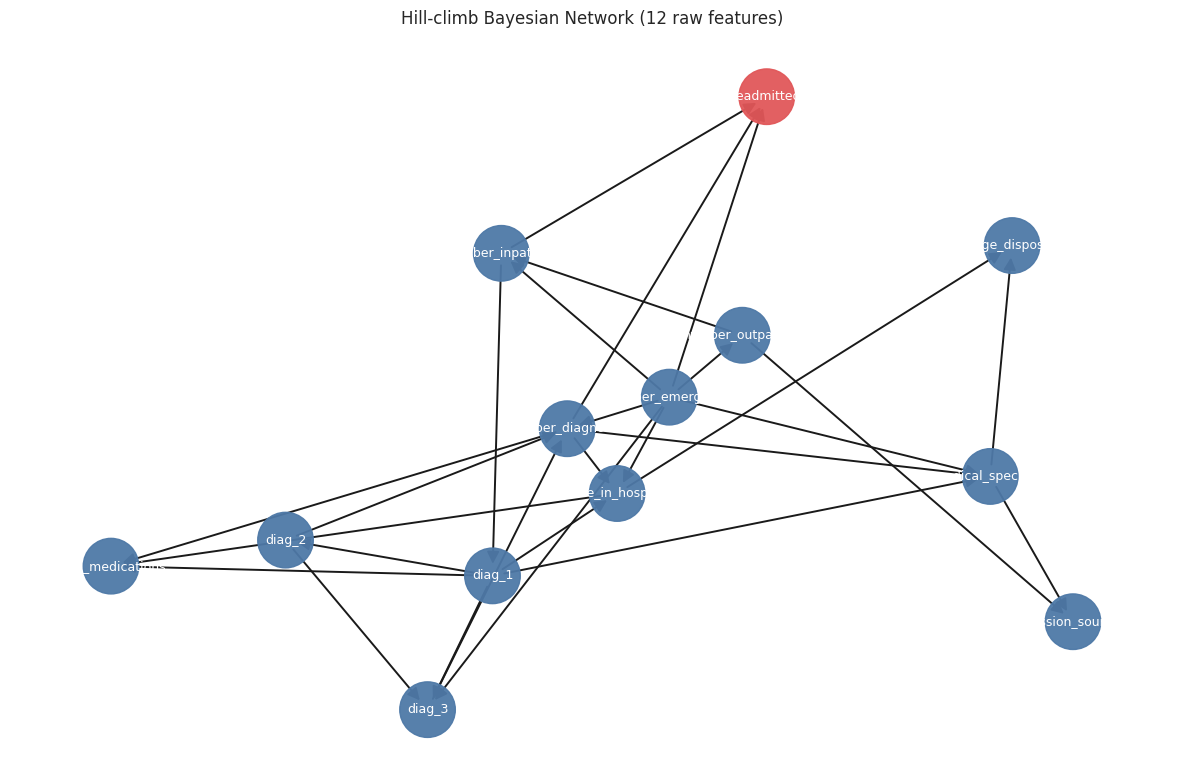

In [34]:
edge_table = pd.DataFrame(final_model.edges(), columns=["parent", "child"])
print(f"Learned {len(edge_table)} edges")
display(edge_table)

plot_bn_structure(
    final_model,
    title=f"Hill-climb Bayesian Network ({len(best_features)} raw features)",
)

sample_view = test_raw[[col for col in ID_COLUMNS if col in test_raw.columns] + best_features + [TARGET]].reset_index(drop=True)
prob_view = test_probabilities.add_prefix("prob_").reset_index(drop=True)
pred_view = pd.DataFrame({"predicted_readmitted": y_test_pred})

display(pd.concat([sample_view, pred_view, prob_view], axis=1).head(20))

## Optional Export

Run this if you want to download the trained model bundle from Colab. It includes the pgmpy model, selected raw features, and the preprocessing object needed to prepare new raw rows the same way.

In [35]:
MODEL_BUNDLE_PATH = "/content/raw_hill_climb_bn_model.pkl"

model_bundle = {
    "model": final_model,
    "preprocessor": final_preprocessor,
    "features": best_features,
    "target": TARGET,
    "selection_results": selection_results,
    "test_metrics": test_metrics,
}

joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
print(f"Saved model bundle to {MODEL_BUNDLE_PATH}")

try:
    from google.colab import files
    files.download(MODEL_BUNDLE_PATH)
except Exception:
    print("Not running in Colab or download unavailable. The file was still saved locally.")

Saved model bundle to /content/raw_hill_climb_bn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>